In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI

**add_messages** is a reducer.

It is used to manage  the chat history. 

**operator.add** also provide the same feature but **add_messages** is provided by langgraph itself and is more optimized

In [2]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage],add_messages]

In [3]:
# chat node Agent
llm = ChatOpenAI()

def chat_node(state: ChatState):

    # take user query from state
    messages = state['messages']


    # send to llm
    response = llm.invoke(messages)

    # response store state
    return { 'messages': [response]}



In [4]:
graph = StateGraph(ChatState)

#add_nodes
graph.add_node('chat_node', chat_node)

# add edges

graph.add_edge(START, 'chat_node')
graph.add_edge ('chat_node', END)


chatbot_wf = graph.compile()



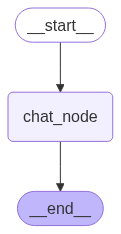

In [5]:
from IPython.display import Image, display
display(Image(chatbot_wf.get_graph().draw_mermaid_png()))

In [6]:
initial_state = { 
    'messages': [HumanMessage(content='What is the capital of India')]
}

chatbot_wf.invoke(initial_state)['messages']

[HumanMessage(content='What is the capital of India', additional_kwargs={}, response_metadata={}, id='a03cd40e-4683-43f2-a12f-83811f39ed99'),
 AIMessage(content='The capital of India is New Delhi.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 13, 'total_tokens': 21, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='run--5c96aaba-1586-477b-8fd9-7594dda3885b-0', usage_metadata={'input_tokens': 13, 'output_tokens': 8, 'total_tokens': 21, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]

In [11]:
chatbot_wf.invoke(initial_state)['messages'][-1].content

'New Delhi'

Now we will try to create a loop which will do the chat unless user EXIT

In [12]:
while True:

    user_message = input('Type here: ')

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break

    response = chatbot_wf.invoke({'messages': [HumanMessage(content=user_message)]})

    print('AI: ', response['messages'][-1].content)








AI:  Hello! How can I assist you today?
AI:  The capital of India is New Delhi.
AI:  The capital of America is Washington, D.C.
AI:  Generative AI refers to a type of artificial intelligence that is programmed to generate and create new content, such as images, music, text, video, etc., rather than analyzing existing data or making decisions based on input. Generative AI uses algorithms and deep learning techniques to produce new content that is unique and original.

One common example of generative AI is a deep learning model called a Generative Adversarial Network (GAN), which consists of two neural networks – a generator and a discriminator. The generator network generates new content, such as images, while the discriminator network evaluates the authenticity of the generated content. The two networks are trained simultaneously in a competitive manner, with the generator trying to fool the discriminator into believing that its generated content is real.

Generative AI has a wide ran

the chatbot looks good, but there are some major problems with this chat bot

In [13]:
while True:

    user_message = input('Type here: ')

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break

    response = chatbot_wf.invoke({'messages': [HumanMessage(content=user_message)]})

    print('AI: ', response['messages'][-1].content)


AI:  Hello Akash, nice to meet you! How can I help you today?
AI:  I'm sorry, but I do not have the ability to determine your name as I do not have access to personal information. If you would like to share your name with me, feel free to do so.


In [14]:
response['messages']

[HumanMessage(content='Can you tell me my name', additional_kwargs={}, response_metadata={}, id='e17c1bcd-c0c7-467c-b066-87b90c2db838'),
 AIMessage(content="I'm sorry, but I do not have the ability to determine your name as I do not have access to personal information. If you would like to share your name with me, feel free to do so.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 13, 'total_tokens': 55, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='run--2cab8b34-ce4c-4c54-8fe9-ca3d1d1a5063-0', usage_metadata={'input_tokens': 13, 'output_tokens': 42, 'total_tokens': 55, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'aud

observe it does not even remember the last conversation

In [15]:
while True:

    user_message = input('Type here: ')

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break

    response = chatbot_wf.invoke({'messages': [HumanMessage(content=user_message)]})

    print('AI: ', response['messages'][-1].content)

AI:  110
AI:  I'm sorry, but I am not able to perform mathematical calculations myself. If you add 50 to the number you have in mind, you will get the result of your calculation.


observe here also it was not able to add 50 to 110 

so it does not remember the context even after sending the full context


the reason is in every iteration we are invoking the message in the loop, and once the invoke gets executed, it starts next iteration from the scratch and all the previous context is getting erased.


Here we will use the concept of PERSISTENCE

which means that we can store the STATE either in a 
- Database
- RAM



In [16]:
from langgraph.checkpoint.memory import MemorySaver

In [17]:
checkpointer = MemorySaver() # memory component

graph = StateGraph(ChatState)

#add_nodes
graph.add_node('chat_node', chat_node)

# add edges

graph.add_edge(START, 'chat_node')
graph.add_edge ('chat_node', END)


chatbot_memory_wf = graph.compile(checkpointer=checkpointer) 



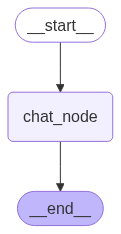

In [18]:
from IPython.display import Image, display
display(Image(chatbot_memory_wf.get_graph().draw_mermaid_png()))

to use the memory element we will create 
-  **thread_id** this will keep the context for current session. Eg: If we initiate a new chat in chatGPT then it will manage the session for it.

- **config** : this is a configurable dictionary which will indicate the **thread_id** which we will pass as the context to the invoke(), so that it will always answer in the context 

In [20]:
thread_id = '1'

while True:

    user_message = input('Type here: ')

    print('User:', user_message)

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break


    config = {'configurable': {'thread_id': thread_id}}
    response = chatbot_memory_wf.invoke({'messages': [HumanMessage(content=user_message)]}, config=config)

    print(response['messages'][-1].content)








User: Hi my name is akash
Hello Akash! How are you doing today?
User: can you tell me my name
Yes, your name is Akash.
User: ok, can you add 10 to  50
Sure, 10 + 50 equals 60.
User: ok now add 90 in the previous
Adding 90 to the previous result of 60 gives a total of 150.
User: bye


now the entire conversation history is available to the chat bot

In [22]:
chatbot_memory_wf.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='Hi my name is Akash', additional_kwargs={}, response_metadata={}, id='1bd51688-6569-4205-88ec-46c89b0d0625'), AIMessage(content='Hello Akash, nice to meet you! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 13, 'total_tokens': 29, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='run--46174c5e-8e47-4bcd-b3c6-5c94a0cdfc4a-0', usage_metadata={'input_tokens': 13, 'output_tokens': 16, 'total_tokens': 29, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}), HumanMessage(content='Hi my name is akash', additional_kwargs={}

here we are using RAM to store the data, but in production grade chatbot we use Databases.

For example: A customer is checking his refund status for 2nd time with chatbot, in that case the chatbot need to retrieve the context of previous conversation from Databases.